# RGCN



In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import time
import numpy as np

from torch_geometric.nn import RGCNConv
from torch_geometric.utils import negative_sampling

from sklearn.metrics import roc_auc_score, average_precision_score, f1_score


In [2]:
# Carregar os itens salvos do outro notebook
checkpoint = torch.load('dados_prontos.pt', weights_only=False)
train_data = checkpoint['train_data']
val_data = checkpoint['val_data']
test_data = checkpoint['test_data']

# Parâmetros baseados no processamento de dados
in_channels = 1024       # Morgan Fingerprints
num_relations = 1317     # Efeitos colaterais
hidden_channels = 64     # Tamanho da camada interna
out_channels = 32        # Tamanho do embedding final da droga

In [3]:
# Configuração de Hiperparâmetros e Dimensões
data = train_data # Conjunto de treino
num_nodes = data.num_nodes # Numero total de drogas
num_relations = num_relations # Numero de tipos de arestas

### Classe Net (cérebro)

    - Começa definindo as portas de entrada (__init__)
    - Cria a primeira camada (conv1) que resume 1024 em 64
    - Cria a segunda camada (conv2) que resume 64 em 32
    - Cria um espaço na memoria pra salvar uma assionatura de cada efeito (rel_distmult)
    - Encode: recebe os parametros, faz a mistura + ReLU (filtra ruídos) e gera o embedding
    - Decode: Recebe um par de drogas, pega os embeddings das duas drogas e calcula o score

In [4]:
class Net(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, num_relations):
        super().__init__()

        # AMPLIFICADOR
        self.lin_input = torch.nn.Linear(in_channels, hidden_channels)
        self.bn1 = torch.nn.BatchNorm1d(hidden_channels)
        
        # ENCODER
        # Primeira camada recebe os 1024 bits e transforma em 64 características
        self.conv1 = RGCNConv(hidden_channels, hidden_channels, num_relations, num_bases=30)

        # Segunda camada refina os 64 dados para um Embedding final de 64 numeros 
        self.conv2 = RGCNConv(hidden_channels, out_channels,   num_relations, num_bases=30)

        # Camada de Dropout (X de chance de desligar um neurônio)
        self.dropout = torch.nn.Dropout(0.2)
        
        # DECODER
        # Parametro DistMult cria uma assinatura para cada um dos 1317 efeitos
        # É uma matriz onde cada liha representa um efeito especifico
        self.rel_distmult = nn.Parameter(torch.Tensor(num_relations, out_channels))

        # Para os pesos não ficarem zerados
        nn.init.xavier_uniform_(self.rel_distmult)

    def encode(self, x, edge_index, edge_type):
        """Transforma a química e as conexões em um vetor de identidade (Embedding)"""
        
        x = self.lin_input(x)
        x = self.bn1(x).relu() # Força o sinal a aparecer
        x = self.dropout(x)
        
        # Passa pela primeira camada e aplica a função de ativação ReLU
        x = self.conv1(x, edge_index, edge_type).relu()
        x = self.dropout(x)
        # Passa pela segunda camada para gerar o embedding final
        x = self.conv2(x, edge_index, edge_type)
        return F.normalize(x, p=2, dim=-1)

    def decode(self, z, edge_label_index, edge_label_type):
        """Calcula a probabilidade de uma interação existir entre duas drogas"""
        # z: são os embeddings de todas as drogas calculados no encode
        
        # Pegamos os embeddings das drogas que queremos testar (Pares de Origem e Destino)
        u = z[edge_label_index[0]] # Droga A
        v = z[edge_label_index[1]] # Droga B
        
        # Pegamos a assinatura do efeito colateral que estamos testando
        rel = self.rel_distmult[edge_label_type]
        
        # Fórmula DistMult: Multiplica a Droga A pela Assinatura do Efeito e pela Droga B.
        # Se o resultado for alto, a chance de interação é alta.
        return (u * rel * v).sum(dim=-1)
            

In [5]:
# Dispositivo com prioridade em GPU/CUDA
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Rodando em: {device}")

Rodando em: cuda


In [6]:
# Normalizando os numeros ADICAO 
train_data.x = torch.nn.functional.normalize(train_data.x, p=2, dim=-1)
val_data.x = torch.nn.functional.normalize(val_data.x, p=2, dim=-1)
test_data.x = torch.nn.functional.normalize(test_data.x, p=2, dim=-1)

# Criando o modelo
model = Net(in_channels=1024, 
            hidden_channels=64, # 64 , 32 | 128 , 64 | 64 , 64 |
            out_channels=64, 
            num_relations=1317).to(device)

# Configurando o Otimizador
# Aqui utilizaremos o Adam
optimizer = torch.optim.Adam(model.parameters(), lr=0.0005, weight_decay=0.0001) 
# valores do otimizador: 0.1, 0.0005 | 0.0005 , 0.0001 | 0.0001 , 0.001 | 0.0002 , 0.001 | 0.0001 , 0.0001

In [7]:
def train():
    # Inicia o modelo no modo de treino
    model.train()
    optimizer.zero_grad()

    # Encode (Gera os embeddings)
    z = model.encode(train_data.x, train_data.edge_index, train_data.edge_type)
    pos_edge_index  = train_data.edge_label_index
    edge_label_type = train_data.edge_label_type.to(device)
    
    # Negative Sampling
    num_neg_samples = pos_edge_index.size(1)
    neg_edge_index = torch.stack([
        torch.randint(0, num_nodes, (num_neg_samples,), device=device),
        torch.randint(0, num_nodes, (num_neg_samples,), device=device),
    ], dim=0)

    perm = torch.randperm(edge_label_type.size(0), device=device)[:num_neg_samples]
    neg_edge_type = edge_label_type[perm]

    # Decode (Calcula o score para as arestas reais e falsas)
    pos_out = model.decode(z, pos_edge_index, edge_label_type)
    neg_out = model.decode(z, neg_edge_index, neg_edge_type)

    # Loss (Calcula o erro)
    out = torch.cat([pos_out, neg_out])
    label = torch.cat([
        torch.ones(pos_out.size(0)),
        torch.zeros(neg_out.size(0))
    ]).to(device)
    
    loss = F.binary_cross_entropy_with_logits(out, label) 
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()

    return loss.item()


@torch.no_grad()
def test(data_set):
    # Coloca o modelo em modo de avaliação
    model.eval()

    # Gera os embeddings
    z = model.encode(data_set.x, data_set.edge_index, data_set.edge_type)

    # Negative Sampling
    pos_edge_index = data_set.edge_label_index
    edge_label_type = data_set.edge_label_type.to(device)
    num_neg_samples = pos_edge_index.size(1)
    
    # Criando exemplos falsos para o teste 
    neg_edge_index = torch.stack([
        torch.randint(0, num_nodes, (num_neg_samples,), device=device),
        torch.randint(0, num_nodes, (num_neg_samples,), device=device),
    ], dim=0)

    perm = torch.randperm(edge_label_type.size(0), device=device)[:num_neg_samples]
    neg_edge_type = edge_label_type[perm]
    
    # Calculamos o score para os reais e para os falsos
    pos_out = model.decode(z, pos_edge_index, edge_label_type)
    neg_out = model.decode(z, neg_edge_index, neg_edge_type)
    
    # Juntamos tudo 
    out    = torch.cat([pos_out, neg_out]).cpu()
    y_true = torch.cat([
        torch.ones(pos_out.size(0)),
        torch.zeros(neg_out.size(0))
    ]).cpu()
    
    # Converte a saída logits para probabilidades (0 a 1) usando sigmoid
    probs = torch.sigmoid(out).numpy()
    labels = y_true.numpy()
    
    # Cria previsões binárias para o F1-score (maior que 50% de chance vira 1, senão 0)
    preds = (probs > 0.5).astype(int)
    
    # Calcula as três métricas
    auc = roc_auc_score(labels, probs)
    aupr = average_precision_score(labels, probs)
    f1 = f1_score(labels, preds)

    return auc, aupr, f1

In [8]:
# Garantindo que os conjuntos estão no mesmo dispositvo
train_data = train_data.to(device)
val_data = val_data.to(device)
test_data = test_data.to(device)

## Verificação de Valores

In [9]:
print(f"--- Diagnóstico de train_data.x ---")
print(f"Tem algum valor NaN (nulo)?: {torch.isnan(train_data.x).any()}")
print(f"Tem algum valor Infinito?: {torch.isinf(train_data.x).any()}")
print(f"Valor Máximo: {train_data.x.max().item()}")
print(f"Valor Mínimo: {train_data.x.min().item()}")
print(f"Média dos valores: {train_data.x.mean().item():.4f}")

--- Diagnóstico de train_data.x ---
Tem algum valor NaN (nulo)?: False
Tem algum valor Infinito?: False
Valor Máximo: 1.0
Valor Mínimo: 0.0
Média dos valores: 0.0063


In [10]:
num_rel_real = int(train_data.edge_type.max()) + 1

print(f"Número real de relações detectadas: {num_rel_real}")

Número real de relações detectadas: 1317


In [11]:
# Quantos por cento dos dados são zeros?
zeros = (train_data.x == 0).sum().item()
total = train_data.x.numel()
print(f"Porcentagem de zeros: {(zeros/total)*100:.2f}%")

# Existem colunas que são zero para todos?
colunas_mortas = (train_data.x.sum(dim=0) == 0).sum().item()
print(f"Colunas 'mortas' (todas zero): {colunas_mortas} de {train_data.x.size(1)}")

Porcentagem de zeros: 95.69%
Colunas 'mortas' (todas zero): 0 de 1024


In [12]:
# Verifica se existem linhas duplicadas no train_data.x
unique_rows = torch.unique(train_data.x, dim=0)
print(f"Drogas totais: {train_data.x.size(0)}")
print(f"Drogas com 'DNA' único: {unique_rows.size(0)}")

Drogas totais: 645
Drogas com 'DNA' único: 645


In [13]:
import matplotlib.pyplot as plt

# Conta quantas vezes cada relação aparece
rel_counts = torch.bincount(train_data.edge_type)
print(f"Relação mais comum aparece: {rel_counts.max()} vezes")  # INVESTIGAR
print(f"Relação mais rara aparece: {rel_counts.min()} vezes")
print(f"Quantas relações aparecem menos de 10 vezes? {(rel_counts < 10).sum().item()}")

Relação mais comum aparece: 22310 vezes
Relação mais rara aparece: 0 vezes
Quantas relações aparecem menos de 10 vezes? 26


In [14]:
print(f"pos_edge_index shape:  {train_data.edge_label_index.shape}")
print(f"edge_label_type shape: {train_data.edge_label_type.shape}")

pos_edge_index shape:  torch.Size([2, 1756101])
edge_label_type shape: torch.Size([1756101])


## Função Early Stopping

In [15]:
class EarlyStopping:
    def __init__(self, patience=20, path='melhor_modelo.pt'):
        self.patience = patience
        self.path = path
        self.counter = 0
        self.best_score = None
        self.early_stop = False

    def __call__(self, current_score, model):
        if self.best_score is None:
            self.best_score = current_score
            self.save_checkpoint(model)
        # Se o score atual não subiu em relação ao melhor já visto
        elif current_score <= self.best_score:
            self.counter += 1
            print(f"--- Sem melhora por {self.counter} época(s). (Melhor: {self.best_score:.4f}) ---")
            if self.counter >= self.patience:
                self.early_stop = True
        # Se o score atual subiu
        else:
            print(f"+++ AUC subiu de {self.best_score:.4f} para {current_score:.4f}! Salvando... +++")
            self.best_score = current_score
            self.save_checkpoint(model)
            self.counter = 0 # Zera a contagem

    def save_checkpoint(self, model):
        torch.save(model.state_dict(), self.path)

## Loop Principal

In [16]:

# Classe com listas para histórico
historico = {
    'epoch': [],
    'loss': [],
    'auc': [],
    'aupr': [],
    'f1': []
}

early_stopper = EarlyStopping(patience=20, path='melhor_modelo.pt')

print(f"{'Época':<7} | {'Loss':<8} | {'AUC':<7} | {'AUPR':<7} | {'F1':<7} | {'Progresso'}")
print("-" * 75)

melhor_auc = 0.0
inicio = 1
fim = 1000

# Loop principal
for epoch in range(inicio, fim):

    loss = train()
    
    auc, aupr, f1 = test(val_data)

    print(f"{epoch:03d}     | {loss:<8.4f} | {auc:<7.4f} | {aupr:<7.4f} | {f1:<7.4f} | {auc*100:>5.1f}%")

    early_stopper(auc, model)

    if early_stopper.early_stop:
        print(f"\n PARADA: A AUC não subiu por {early_stopper.patience} épocas.")
        break

    # Salvando os valores nas listas respectivas
    historico['epoch'].append(epoch)
    historico['loss'].append(loss)
    historico['auc'].append(auc)
    historico['aupr'].append(aupr)
    historico['f1'].append(f1)

print("-" * 75)
print("Treinamento finalizado!")

Época   | Loss     | AUC     | AUPR    | F1      | Progresso
---------------------------------------------------------------------------
001     | 0.6931   | 0.5294  | 0.5627  | 0.5374  |  52.9%
002     | 0.6930   | 0.5388  | 0.5846  | 0.5485  |  53.9%
+++ AUC subiu de 0.5294 para 0.5388! Salvando... +++
003     | 0.6929   | 0.5425  | 0.5925  | 0.5528  |  54.3%
+++ AUC subiu de 0.5388 para 0.5425! Salvando... +++
004     | 0.6929   | 0.5473  | 0.5967  | 0.5574  |  54.7%
+++ AUC subiu de 0.5425 para 0.5473! Salvando... +++
005     | 0.6928   | 0.5532  | 0.6036  | 0.5610  |  55.3%
+++ AUC subiu de 0.5473 para 0.5532! Salvando... +++
006     | 0.6927   | 0.5599  | 0.6134  | 0.5645  |  56.0%
+++ AUC subiu de 0.5532 para 0.5599! Salvando... +++
007     | 0.6926   | 0.5657  | 0.6211  | 0.5671  |  56.6%
+++ AUC subiu de 0.5599 para 0.5657! Salvando... +++
008     | 0.6926   | 0.5726  | 0.6305  | 0.5720  |  57.3%
+++ AUC subiu de 0.5657 para 0.5726! Salvando... +++
009     | 0.6925   | 0.5785 

In [17]:
# Testando com os de teste
model.load_state_dict(torch.load('melhor_modelo.pt'))

auc_final, aupr_final, f1_final = test(test_data)

print(f"{'='*30}")
print(f"   RESULTADOS FINAIS TESTES  ")
print(f"{'='*30}")
print(f"AUC-ROC: {auc_final:.4f}")
print(f"AUPR:    {aupr_final:.4f}")
print(f"F1-Score: {f1_final:.4f}")
print(f"{'='*30}")

   RESULTADOS FINAIS TESTES  
AUC-ROC: 0.8792
AUPR:    0.8452
F1-Score: 0.8279


## Geração de Gráficos

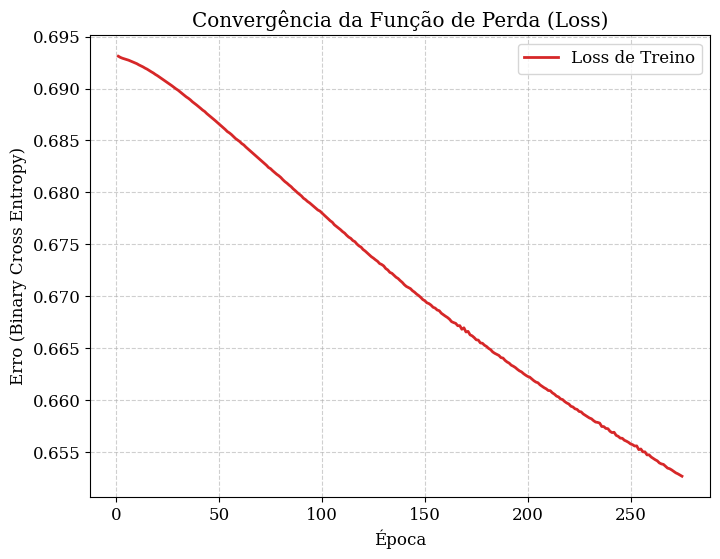

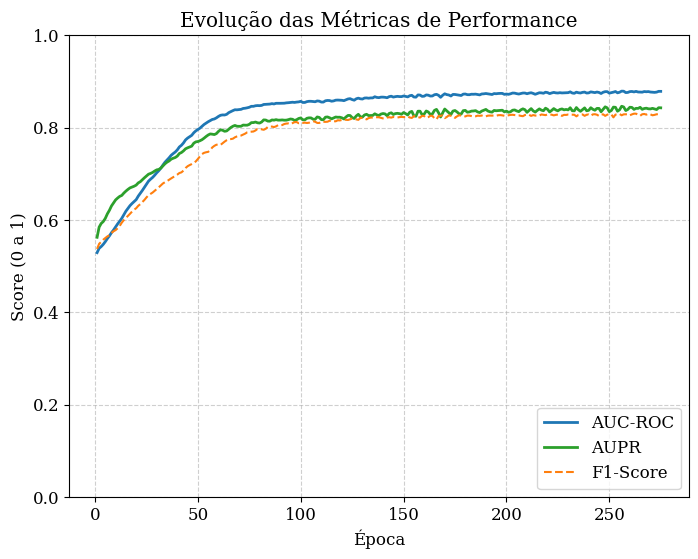

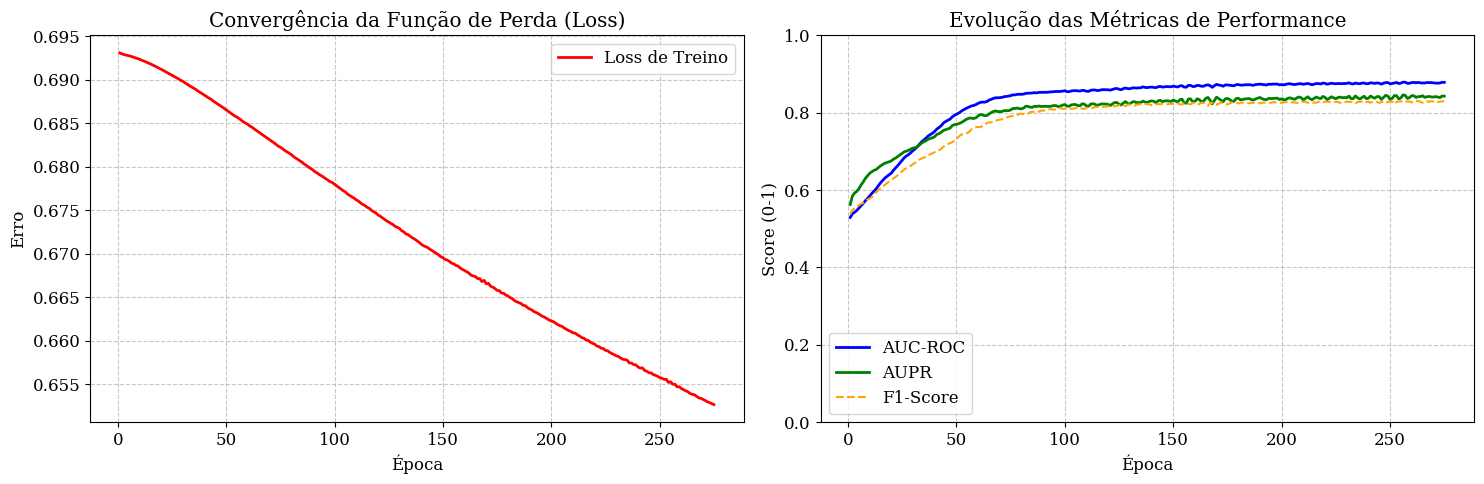

In [20]:
plt.rcParams.update({'font.size': 12, 'font.family': 'serif'})

# 1. GERANDO E SALVANDO O GRÁFICO DE LOSS
plt.figure(figsize=(8, 6))
plt.plot(historico['epoch'], historico['loss'], label='Loss de Treino', color='#d62728', linewidth=2)
plt.title('Convergência da Função de Perda (Loss)')
plt.xlabel('Época')
plt.ylabel('Erro (Binary Cross Entropy)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# Salva em 300 DPI (ideal para documentos impressos)
plt.savefig('grafico_loss_ddi.png', dpi=300, bbox_inches='tight')
plt.show()

# ---------------------------------------------------------

# 2. GERANDO E SALVANDO O GRÁFICO DE MÉTRICAS (AUC, AUPR, F1)
plt.figure(figsize=(8, 6))
plt.plot(historico['epoch'], historico['auc'], label='AUC-ROC', color='#1f77b4', linewidth=2)
plt.plot(historico['epoch'], historico['aupr'], label='AUPR', color='#2ca02c', linewidth=2)
plt.plot(historico['epoch'], historico['f1'], label='F1-Score', color='#ff7f0e', linestyle='--')

plt.title('Evolução das Métricas de Performance')
plt.xlabel('Época')
plt.ylabel('Score (0 a 1)')
plt.ylim(0, 1)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='lower right')

# Salva a segunda imagem
plt.savefig('grafico_metricas_ddi.png', dpi=300, bbox_inches='tight')
plt.show()
gerar_graficos(historico)

# Referências
    - https://pytorch-geometric.readthedocs.io/en/latest/generated/torch_geometric.nn.conv.RGCNConv.html#torch_geometric.nn.conv.RGCNConv
    - https://huggingface.co/riship-nv/RGCN
    - https://docs.pytorch.org/docs/stable/generated/torch.optim.Adam.html
    - https://www.youtube.com/watch?v=MWZakqZDgfQ
    - https://docs.pytorch.org/ignite/generated/ignite.metrics.ROC_AUC.html